In [ ]:


"""
    classification task
        - Cardboard: 461
        - Food Organics: 411
        - Glass: 420
        - Metal: 790
        - Miscellaneous Trash: 495
        - Paper: 500
        - Plastic: 921
        - Textile Trash: 318
        - Vegetation: 436


    data/RealWaste/...

    - load images
    - preprocess images (Resize, Normalie)
    - WasteDataset(Dataset) class
    - Dataset and DataLoaders
    - model arcitecture => AlexNet for now, try others
    - training loop
    - eval performance with metrics 
    
"""



In [1]:

import os

import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
from torch.nn.functional import softmax 
import torch.optim as optim
from torch.utils.data import Dataset, Subset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import time


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device {device}")

Using device cuda


In [2]:

# STEP 1. Load Dataset

DATA_DIR = "data/RealWaste"
base_dataset = datasets.ImageFolder(root= DATA_DIR)

class_names = base_dataset.classes
#print(*class_names)
#print(base_dataset.class_to_idx)

targets = np.array(base_dataset.targets)
counts = Counter(targets)

#print("\nPer-class image counts:")
#for idx, name in enumerate(class_names):
#    print("%21s: %d" % (name, counts[idx]))
print("\nTotal Images: %d" % len(base_dataset))



Total Images: 4757


In [3]:

# STEP 2. Define Transforms

IMAGE_SIZE = 224

IMAGENET_MEAN =  [0.485, 0.456, 0.406] # for r g b value distribution
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean= IMAGENET_MEAN, std= IMAGENET_STD)
])



In [4]:

# STEP 3. Stratified Train/Val/Test Split

class TransformedSubset(Dataset):
    """
        wraps a subset of an untransformed ImageFolder,
        each split can use its transform
    """
    
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

indices = np.arange(len(base_dataset))

# startify, same proportion as the whole dataset

# dataset => 70% train and 30% temp
train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices, targets, test_size= 0.3, stratify= targets, random_state= SEED
)

# 30% temp => 15% val and 15% test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

train_dataset = TransformedSubset(Subset(base_dataset, train_idx), train_transform)
val_dataset = TransformedSubset(Subset(base_dataset, val_idx), eval_transforms)
test_dataset = TransformedSubset(Subset(base_dataset, test_idx), eval_transforms)



Train: 3329 | Val: 714 | Test: 714


In [5]:


# STEP 5. Build DataLoader
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, 
    batch_size= BATCH_SIZE, 
    shuffle= True, 
    num_workers= NUM_WORKERS,
    pin_memory= True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size= BATCH_SIZE,
    shuffle= False,
    num_workers= NUM_WORKERS,
    pin_memory= True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size= BATCH_SIZE,
    shuffle= False,
    num_workers= NUM_WORKERS,
    pin_memory= True
)



In [6]:


# STEP 6. Model

# class WasteCNN(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         self.features = nn.Sequential(
#             # Block 1: 256x256 -> 128x128
#             nn.Conv2d(3, 32, kernel_size= 3, padding= 1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
            
#             nn.Conv2d(32, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
            
#             nn.MaxPool2d(2),
#             # ***
            
#             # Block 2: 128x128 -> 64x64
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(64, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(2),

#             # Block 3: 64x64 -> 32x32
#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(128, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(2),

#             # Block 4: 32x32 -> 16x16
#             nn.Conv2d(128, 256, kernel_size=3, padding=1),
#             nn.BatchNorm2d(256),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(2),
#         )
        
#         self.classifier = nn.Sequential(
#             nn.AdaptiveAvgPool2d((1, 1)),
#             nn.Flatten(),
#             nn.Dropout(0.4),
#             nn.Linear(256, 128),
#             nn.ReLU(inplace=True),
#             nn.Dropout(0.3),
#             nn.Linear(128, num_classes),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.classifier(x)
#         return x

# model = WasteCNN(num_classes=len(class_names)).to(device)
# print(model)

# ******** Alternative: transfer learning ********
def build_resnet_model(num_classes, freeze_backbone= True):
    backbone = models.resnet18(weights= models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in backbone.parameters():
            param.requires_grad = False
        
        # unfreeze last 2 blocks
        for param in backbone.layer3.parameters():
            param.requires_grad = True

        for param in backbone.layer4.parameters():
            param.requires_grad = True
    
    backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
    return backbone

model = build_resnet_model(num_classes= len(class_names), freeze_backbone= True).to(device)
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [7]:

# STEP 7. Loss, Optimizer, Scheduler

# find each classes inverse ration
class_counts = np.array([counts[i] for i in range(len(class_names))])
class_weights = (class_counts.sum() / len(class_names)) * (1.0 / class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights (higher = rarer class):")
for name, w in zip(class_names, class_weights):
    print(f"  {name:22s}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight= class_weights_tensor)
optimizer = optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3},
    ],
    weight_decay= 1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode= "min", factor= 0.5, patience= 3)

# "best_waste_cnn.pt"
CHECKPOINT_PATH = "res_left_over.pt"



Class weights (higher = rarer class):
  Cardboard             : 1.134
  Food Organics         : 1.286
  Glass                 : 1.258
  Metal                 : 0.669
  Miscellaneous Trash   : 1.068
  Paper                 : 1.057
  Plastic               : 0.574
  Textile Trash         : 1.662
  Vegetation            : 1.212


In [8]:


# STEP 8. Training Loop

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


NUM_EPOCHS = 30
PATIENCE = 7

best_val_loss = float("inf")
epochs_no_improve = 0
history = {
    "train_loss": [], 
    "train_acc": [], 
    "val_loss": [], 
    "val_acc": []
}

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.perf_counter()
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    end_time = time.perf_counter()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    execution_time = end_time - start_time

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | Execution Time: {execution_time:.6f} seconds"
          f"\n  train_loss= {train_loss:.4f} train_acc= {train_acc:.4f}"
          f"\n  val_loss= {val_loss:.4f} val_acc= {val_acc:.4f} \n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}")
            break



Epoch 01/30 | Execution Time: 26.356147 seconds
  train_loss= 0.8658 train_acc= 0.6819
  val_loss= 0.4674 val_acc= 0.8473 

Epoch 02/30 | Execution Time: 24.989715 seconds
  train_loss= 0.2313 train_acc= 0.9225
  val_loss= 0.3691 val_acc= 0.8739 

Epoch 03/30 | Execution Time: 25.344418 seconds
  train_loss= 0.0788 train_acc= 0.9799
  val_loss= 0.3460 val_acc= 0.8824 

Epoch 04/30 | Execution Time: 25.297213 seconds
  train_loss= 0.0371 train_acc= 0.9913
  val_loss= 0.3644 val_acc= 0.8782 

Epoch 05/30 | Execution Time: 26.126570 seconds
  train_loss= 0.0249 train_acc= 0.9952
  val_loss= 0.3549 val_acc= 0.8796 

Epoch 06/30 | Execution Time: 26.186547 seconds
  train_loss= 0.0183 train_acc= 0.9955
  val_loss= 0.4114 val_acc= 0.8782 

Epoch 07/30 | Execution Time: 25.228848 seconds
  train_loss= 0.0137 train_acc= 0.9976
  val_loss= 0.4123 val_acc= 0.8782 

Epoch 08/30 | Execution Time: 25.727648 seconds
  train_loss= 0.0072 train_acc= 0.9991
  val_loss= 0.4330 val_acc= 0.8824 

Epoch 09

In [9]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location= device))

<All keys matched successfully>

In [10]:

# STEP 9. Evaluate on the test set
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro")

print(f"Test accuracy:    {test_accuracy:.4f}")
print(f"Macro precision:  {precision:.4f}")
print(f"Macro recall:     {recall:.4f}")
print(f"Macro F1:         {f1:.4f}")
print("\nPer-class report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))



Test accuracy:    0.9034
Macro precision:  0.9066
Macro recall:     0.9113
Macro F1:         0.9077

Per-class report:

                     precision    recall  f1-score   support

          Cardboard       0.98      0.93      0.96        70
      Food Organics       0.89      0.95      0.92        61
              Glass       0.89      0.90      0.90        63
              Metal       0.89      0.89      0.89       118
Miscellaneous Trash       0.89      0.76      0.82        75
              Paper       0.95      0.95      0.95        75
            Plastic       0.87      0.88      0.87       139
      Textile Trash       0.85      0.96      0.90        48
         Vegetation       0.94      0.98      0.96        65

           accuracy                           0.90       714
          macro avg       0.91      0.91      0.91       714
       weighted avg       0.90      0.90      0.90       714



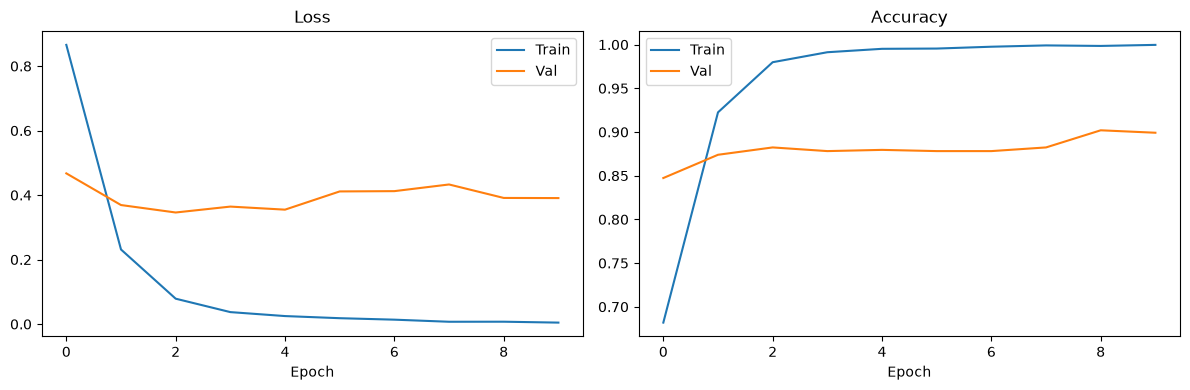

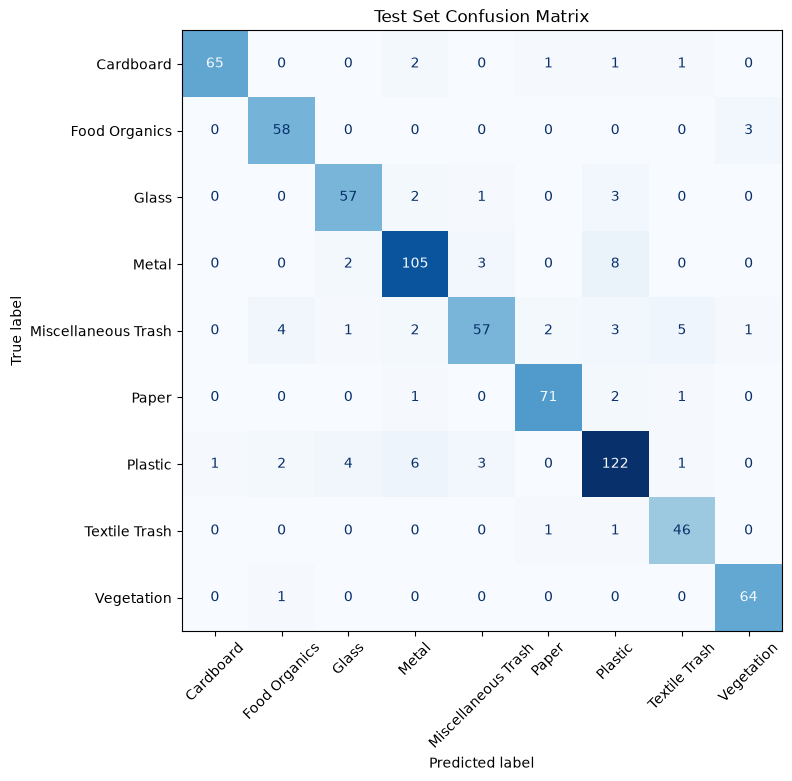

In [11]:


# STEP 10. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()



In [57]:

print("Traning size:    %6d batches" % (len(train_loader)))
print("Validation size: %6d batches" % (len(val_loader)))
print("Test size:       %6d batches" % (len(test_loader)))


Traning size:       105 batches
Validation size:     23 batches
Test size:           23 batches


The execution time of model: 0.003005 seconds 

Cardboard: 0.0000
Food Organics: 0.0000
Glass: 0.0000
Metal: 0.0000
Miscellaneous Trash: 0.0000
Paper: 0.9998
Plastic: 0.0000
Textile Trash: 0.0001
Vegetation: 0.0000


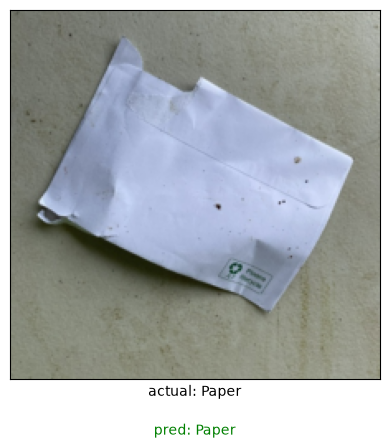

In [19]:

# ... a random image from test_dataset
start_timer = 0.0; end_timer = 0.0; execution_time = 0.0

n_samples = len(test_loader.dataset)
sample_idx = random.randrange(n_samples) # 0 to n_samples - 1

s_image, s_label = test_loader.dataset[sample_idx]
s_image = s_image.unsqueeze(0).to(device) # [channel_size, image_size, image_size] => [1, 3, 256, 256]


model.eval()
with torch.no_grad():
    start_timer = time.perf_counter()
    #
    output = model(s_image) # output.shape = [1, 9]
    #
    end_timer = time.perf_counter()
    
    pred = output.argmax(dim= 1).item()

execution_time = end_timer - start_timer
print("The execution time of model: %.6f seconds \n" % execution_time)

probs = softmax(output, dim= 1)
probs_np = probs.squeeze(0).cpu().numpy()

for idx, confidence in enumerate(probs_np):
    print(f"{class_names[idx]}: {confidence:.4f}")
    

mean = np.array(IMAGENET_MEAN)
std = np.array(IMAGENET_STD)
img = s_image.squeeze(0).permute(1, 2, 0).cpu().numpy() # shape => [image_size, image_size, channel_size]
img = std * img + mean
img = np.clip(img, 0, 1)

plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.xlabel(f"actual: {class_names[s_label]}")
plt.gca().text(
    0.5, 
    -0.12,
    f"pred: {class_names[pred]}",
    color= "green" if (pred == s_label) else "red",
    ha= "center",
    va= "top",
    transform= plt.gca().transAxes,
)

plt.show()

